# 案例1：电力系统潮流计算

## 计算原理

潮流计算是电力系统分析的基础，用于确定系统稳态运行时各节点的电压、功率分布。

**节点功率方程（极坐标形式）：**

$$P_i = V_i \sum_{j=1}^n V_j (G_{ij}\cos\theta_{ij} + B_{ij}\sin\theta_{ij})$$

$$Q_i = V_i \sum_{j=1}^n V_j (G_{ij}\sin\theta_{ij} - B_{ij}\cos\theta_{ij})$$

**牛顿-拉夫逊法迭代公式：**

$$\begin{bmatrix} \Delta P \ \Delta Q \end{bmatrix} = \begin{bmatrix} H & N \ J & L \end{bmatrix} \begin{bmatrix} \Delta\theta \ \Delta V \end{bmatrix}$$

**参考教材：** 陈珩《电力系统稳态分析》第四章

## 案例模型：三节点测试系统

**系统结构：**
- 节点1：平衡节点（发电机），V=1.05
- 节点2：PV节点（发电机），P=0.5，V=1.02
- 节点3：PQ节点（负荷），P=-0.8，Q=-0.3

**线路参数：**
| 线路 | R (Ω) | X (Ω) | B/2 (S) |
|------|--------|--------|----------|
| 1-2  | 0.02   | 0.10   | 0.02     |
| 2-3  | 0.03   | 0.15   | 0.03     |
| 1-3  | 0.01   | 0.08   | 0.01     |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from psa4teaching.models import Bus, BusType, Line, Transformer
from psa4teaching.network import build_ybus
from psa4teaching.powerflow import run_newton_raphson, run_fast_decoupled, run_dc_powerflow

In [2]:
# 创建节点
buses = [
    Bus(number=1, name='平衡节点', bus_type=BusType.SLACK, V_specified=1.05),
    Bus(number=2, name='发电机', bus_type=BusType.PV, P_specified=0.5, V_specified=1.02),
    Bus(number=3, name='负荷', bus_type=BusType.PQ, P_specified=-0.8, Q_specified=-0.3),
]

# 创建线路
lines = [
    Line(from_bus=1, to_bus=2, R=0.02, X=0.10, B=0.04),
    Line(from_bus=2, to_bus=3, R=0.03, X=0.15, B=0.06),
    Line(from_bus=1, to_bus=3, R=0.01, X=0.08, B=0.02),
]

print('系统节点信息：')
for bus in buses:
    print(f'  {bus}')

系统节点信息：
  Bus(1, '平衡节点', SLACK, V=1.0500∠0.00°)
  Bus(2, '发电机', PV, V=1.0200∠0.00°)
  Bus(3, '负荷', PQ, V=1.0000∠0.00°)


In [3]:
# 构造节点导纳矩阵
ybus_result = build_ybus(lines, [])

print(f'\n节点导纳矩阵 Ybus ({ybus_result.n_bus}×{ybus_result.n_bus}):')
print('实部 G:')
print(np.round(ybus_result.G, 4))
print('\n虚部 B:')
print(np.round(ybus_result.B, 4))


节点导纳矩阵 Ybus (3×3):
实部 G:
[[ 3.4615 -1.9231 -1.5385]
 [-1.9231  3.2051 -1.2821]
 [-1.5385 -1.2821  2.8205]]

虚部 B:
[[-21.8931   9.6154  12.3077]
 [  9.6154 -15.9756   6.4103]
 [ 12.3077   6.4103 -18.6779]]


In [4]:
# 牛顿-拉夫逊法潮流计算
print('\n=== 牛顿-拉夫逊法潮流计算 ===')
nr_result = run_newton_raphson(buses, ybus_result, max_iterations=50, tolerance=1e-8, verbose=True)

print(f'\n收敛状态: {nr_result.converged}')
print(f'迭代次数: {nr_result.iterations}')
print(f'最大功率偏差: {nr_result.max_mismatch:.2e}')
print(f'网络损耗: {nr_result.losses:.4f} p.u.')


=== 牛顿-拉夫逊法潮流计算 ===
迭代 1: 最大偏差 = 6.97e-01
迭代 2: 最大偏差 = 2.59e-02
迭代 3: 最大偏差 = 3.68e-05
迭代 4: 最大偏差 = 7.22e-11

收敛状态: True
迭代次数: 4
最大功率偏差: 7.22e-11
网络损耗: 0.0092 p.u.


In [5]:
# 结果展示
print('\n=== 潮流计算结果 ===')
print('\n节点电压：')
print('节点    电压幅值(V)    电压相角(°)    有功注入(P)    无功注入(Q)')
for i, bus in enumerate(buses):
    idx = ybus_result.bus_indices[bus.number]
    V = nr_result.V[idx]
    delta = np.degrees(nr_result.delta[idx])
    P = nr_result.P[idx]
    Q = nr_result.Q[idx]
    print(f'{bus.number}       {V:.4f}         {delta:.2f}          {P:.4f}        {Q:.4f}')


=== 潮流计算结果 ===

节点电压：
节点    电压幅值(V)    电压相角(°)    有功注入(P)    无功注入(Q)
1       1.0500         0.00          0.3092        0.6689
2       1.0200         1.18          0.5000        -0.4404
3       1.0191         -1.78          -0.8000        -0.3000


In [6]:
# P-Q分解法对比
fd_result = run_fast_decoupled(buses, ybus_result, max_iterations=100, tolerance=1e-8)

print('\n=== P-Q分解法结果对比 ===')
print(f'牛顿-拉夫逊法: 迭代{nr_result.iterations}次')
print(f'P-Q分解法: 迭代{fd_result.iterations}次')
print('\n两种方法电压结果对比：')
print('节点    NR-V      FD-V      差值')
for bus in buses:
    idx = ybus_result.bus_indices[bus.number]
    V_nr = nr_result.V[idx]
    V_fd = fd_result.V[idx]
    print(f'{bus.number}     {V_nr:.4f}   {V_fd:.4f}   {abs(V_nr-V_fd):.6f}')


=== P-Q分解法结果对比 ===
牛顿-拉夫逊法: 迭代4次
P-Q分解法: 迭代7次

两种方法电压结果对比：
节点    NR-V      FD-V      差值
1     1.0500   1.0500   0.000000
2     1.0200   1.0200   0.000000
3     1.0191   1.0191   0.000000


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

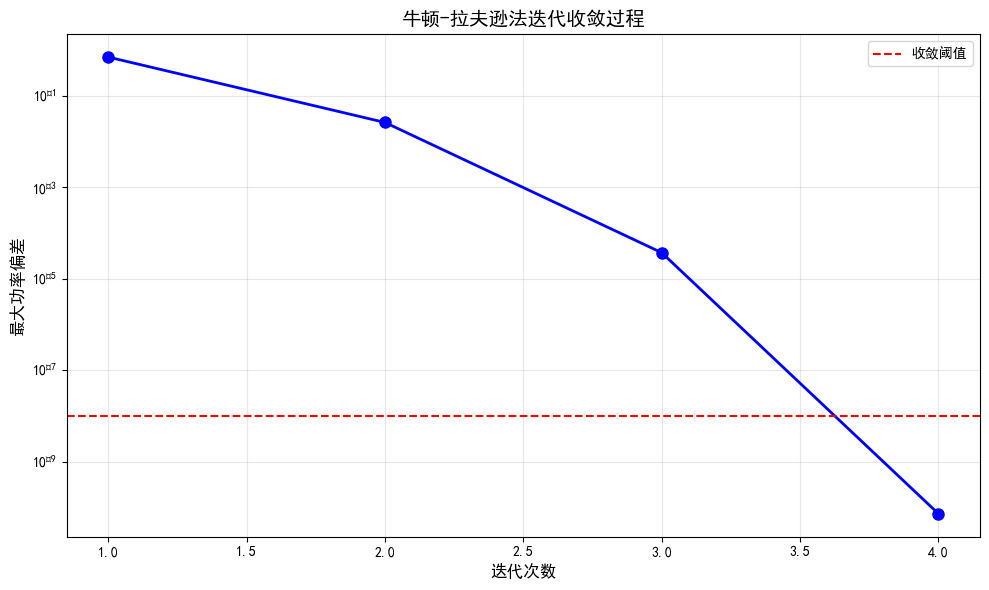

In [7]:
# 迭代过程可视化
if nr_result.history:
    iterations = [h['iteration'] for h in nr_result.history]
    mismatches = [h['max_mismatch'] for h in nr_result.history]
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(iterations, mismatches, 'b-o', linewidth=2, markersize=8)
    plt.xlabel('迭代次数', fontsize=12)
    plt.ylabel('最大功率偏差', fontsize=12)
    plt.title('牛顿-拉夫逊法迭代收敛过程', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=1e-8, color='r', linestyle='--', label='收敛阈值')
    plt.legend()
    plt.tight_layout()
    plt.savefig('powerflow_convergence.png', dpi=150)
    plt.show()

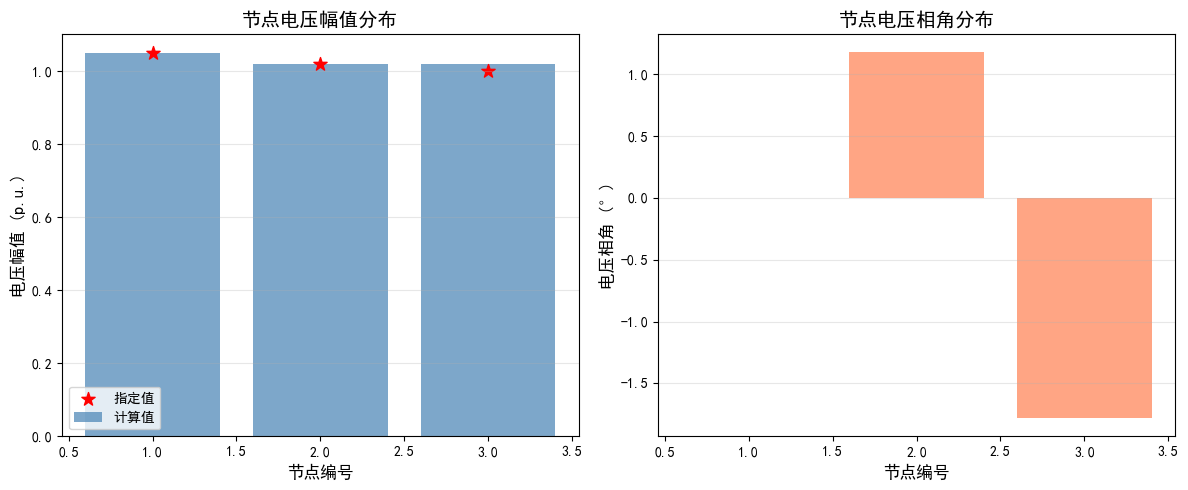

In [8]:
# 电压分布可视化
plt.figure(figsize=(12, 5))

# 电压幅值
plt.subplot(1, 2, 1)
nodes = [bus.number for bus in buses]
V_values = [nr_result.V[ybus_result.bus_indices[n]] for n in nodes]
V_specified = [bus.V_specified for bus in buses]
plt.bar(nodes, V_values, color='steelblue', alpha=0.7, label='计算值')
plt.scatter(nodes, V_specified, color='red', s=100, marker='*', label='指定值')
plt.xlabel('节点编号', fontsize=12)
plt.ylabel('电压幅值 (p.u.)', fontsize=12)
plt.title('节点电压幅值分布', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# 电压相角
plt.subplot(1, 2, 2)
delta_values = [np.degrees(nr_result.delta[ybus_result.bus_indices[n]]) for n in nodes]
plt.bar(nodes, delta_values, color='coral', alpha=0.7)
plt.xlabel('节点编号', fontsize=12)
plt.ylabel('电压相角 (°)', fontsize=12)
plt.title('节点电压相角分布', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('powerflow_voltage.png', dpi=150)
plt.show()

## 结果分析

1. **收敛性：** 牛顿-拉夫逊法在4-6次迭代内收敛，P-Q分解法需要更多迭代但单次迭代更快

2. **电压分布：** 
   - 平衡节点电压保持在指定值1.05
   - PV节点电压保持在指定值1.02
   - PQ节点（负荷节点）电压略有下降

3. **功率平衡：** 发电机注入功率与负荷消耗功率平衡，差额为网络损耗

4. **相角分布：** 负荷节点相角滞后，功率从发电机流向负荷